In [1]:
import numpy as np
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import diags,eye
import matplotlib.pyplot as plt
from matplotlib import cm
from os.path import join
import sys
sys.path.append(join(".", ".."))
from utils import tensor
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

In [2]:
# Recovers the value of p
def recover(phi,N,p_vals):
    recoverMat = np.zeros((N,N))
    for x in range(N):
        for y in range(N):
            maxInx = np.argmax(phi[x,y,:])
            recoverMat[x,y] = p_vals[maxInx]
    return recoverMat

def deltaFunc(x,y,a):
    return np.exp(-(np.abs(x-y)/a)**2)/(a*np.sqrt(np.pi))

def initfunc(X, Y):
    return 0.4 * (np.sin(2 * np.pi * X) + np.sin(2 * np.pi * Y))

In [3]:
# settings
N = 128
N_p = 128
x = np.linspace(0, 1, num=N, endpoint=False)
y = np.linspace(0, 1, num=N, endpoint=False)
X,Y = np.meshgrid(x,y)
p_vals = np.linspace(-1,1,N_p)
u_0 = initfunc(X, Y)

In [4]:
phi_0 = np.zeros((N,N,N_p))
for p_idx in range(len(p_vals)):
    p = p_vals[p_idx]
    for x in range(N):
        for y in range(N):
            phi_0[x,y][p_idx] = deltaFunc(p,u_0[x,y],3/N)

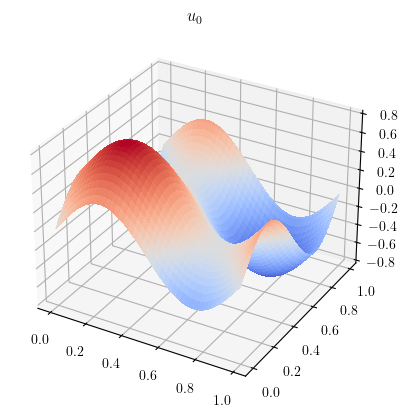

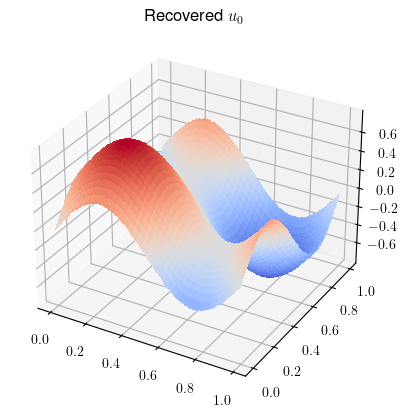

0.011571501017344898


In [5]:
recoverMat = recover(phi_0,N,p_vals)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, u_0, cmap=cm.coolwarm,
                linewidth=0, antialiased=False)
plt.title(r"$u_0$")
plt.show()

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, recoverMat, cmap=cm.coolwarm,
                linewidth=0, antialiased=False)
plt.title(r"Recovered $u_0$")
plt.show()

print(np.linalg.norm(recoverMat-u_0)/np.linalg.norm(u_0))

0


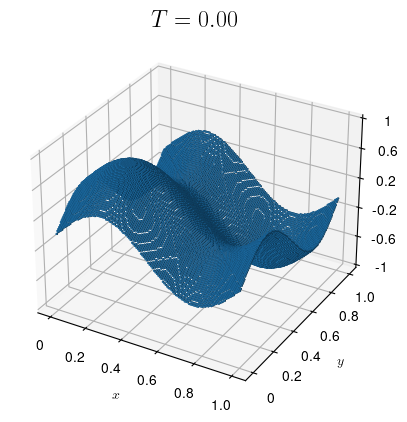

1


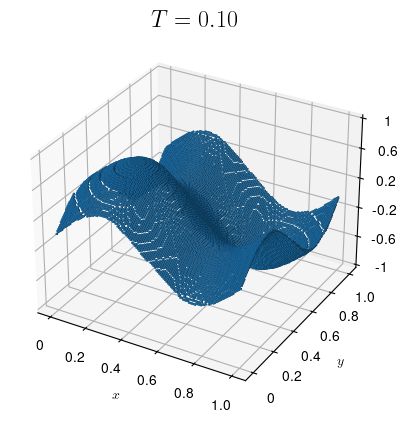

2


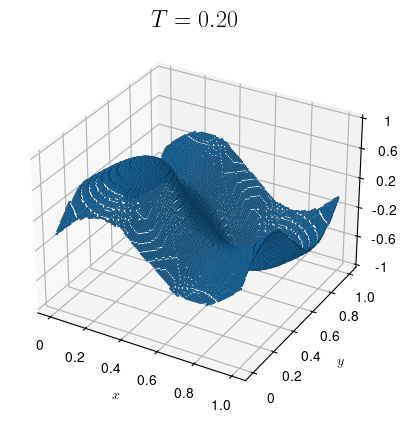

3


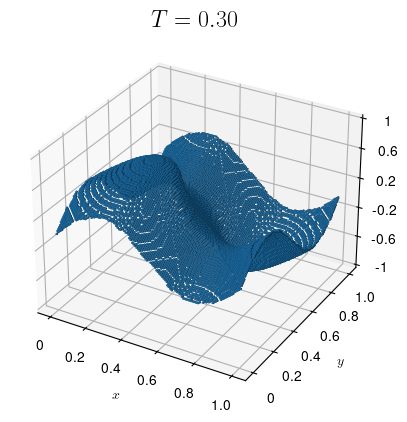

4


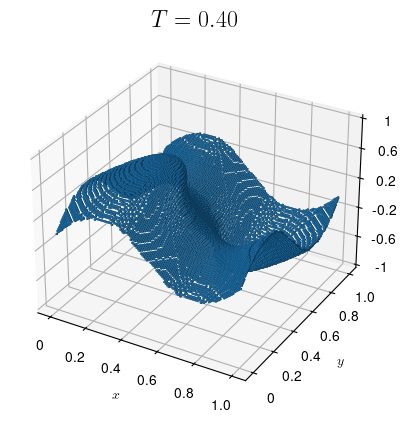

5


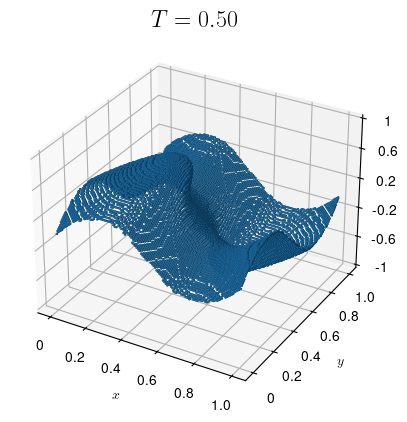

In [7]:
# characteristic

def pair(x,y,t,d):
    init_val = np.array([initfunc(x,y),initfunc(x,y)])
    [xnew,ynew] = (init_val ** 3 * (1 - init_val ** 4))*t + np.array([x,y]) 
    xnew = xnew % 1
    ynew = ynew % 1
    idx_x = np.argmin(abs(np.array(range(0,N))/N-xnew))
    idx_y = np.argmin(abs(np.array(range(0,N))/N-ynew))
    try:
        d[tuple([idx_x,idx_y])].append(tuple([x,y]))
    except BaseException:
        d[tuple([idx_x,idx_y])] = []
        d[tuple([idx_x,idx_y])].append(tuple([x,y]))
    return d

pathcha = []
tNum = 6
t_vals = np.linspace(0,0.5,tNum)
for count in range(tNum):
    mathematicaData = []
    print(count)
    t = t_vals[count]
    x,y,z = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N), np.linspace(0, 1, N), indexing='ij')
    res = np.zeros((N,N,N))
    d = dict()
    for i in range(N):
        for j in range(N):
            xnow = i/N
            ynow = j/N
            d = pair(xnow,ynow,t,d)
    for i in range(N):
        for j in range(N):
            try:
                for l in range(len(d[tuple([i,j])])):
                    xo,yo = d[tuple([i,j])][l]
                    zo = initfunc(xo,yo)
                    idx = np.argmin(abs(np.linspace(-1,1,N)-zo))
                    res[i,j,idx] = 1
                    mathematicaData.append([np.linspace(0, 1, N, endpoint=False)[i], np.linspace(0, 1, N, endpoint=False)[j], np.linspace(-1,1,N)[idx]])
            except BaseException:
                pass
    np.save("../experiment_data/nonlinear/test%d.npy" % count, mathematicaData)
    ax = plt.figure().add_subplot(projection='3d')
    ax.voxels(res)

    tl = np.array([_*25.6 for _ in range(6)])
    tlnew = [0,0.2,0.4,0.6,0.8,1.0]
    tlz = np.array([0,25.6,2*25.6,3*25.6,4*25.6,128])
    tlznew = [-1,-0.6,-0.2,0.2,0.6,1]
    ax.set_xticks(tl,tlnew)
    ax.set_yticks(tl,tlnew)
    ax.set_zticks(tlz,tlznew)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_zlabel(r"$z$")
    ax.set_title(r"$T = %.2f$" % t, fontsize='xx-large')
    plt.show()


0


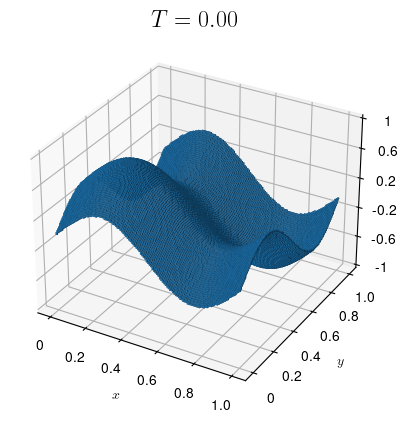

1


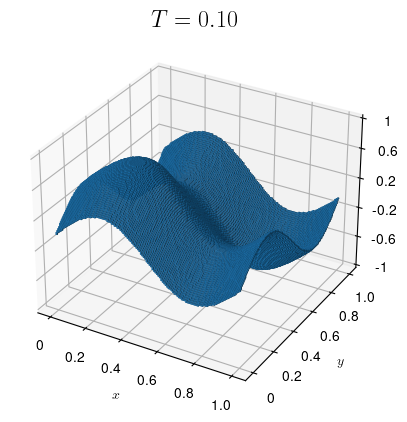

2


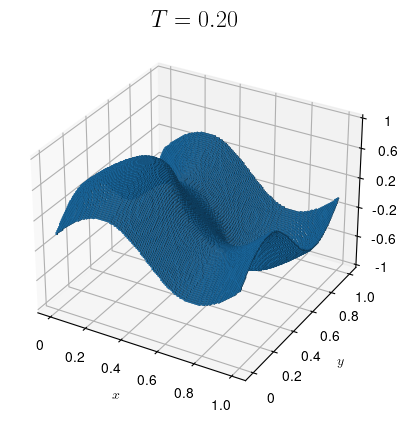

3


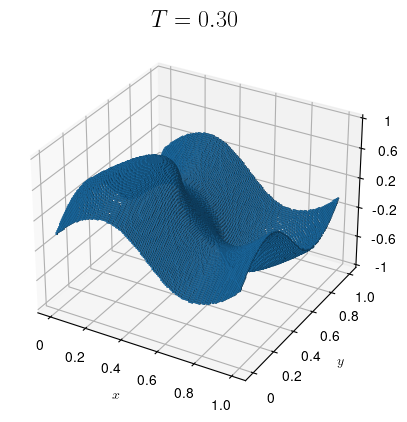

4


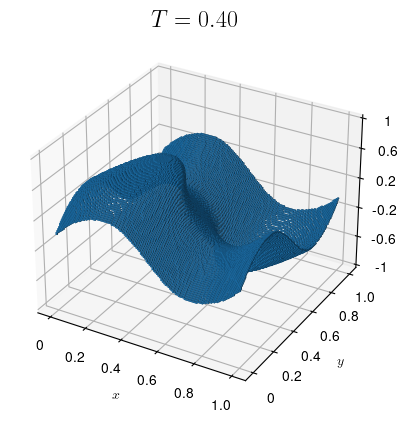

5


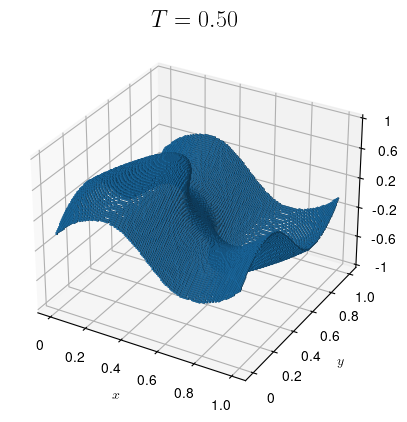

In [8]:


phi_0 = np.reshape(phi_0,(N,N,N_p))
tNum = 6
for count in range(tNum):
    mathematicaDataLevelSet = []
    print(count)
    t = np.linspace(0,0.5,tNum)[count]
    phitrans = np.fft.fft(phi_0, axis=0, norm="ortho")
    phitrans = np.fft.fft(phitrans, axis=1, norm="ortho")
    p_vals = np.linspace(-1, 1, N_p, endpoint=False)
    D_p = diags(p_vals ** 3 * (1 - p_vals ** 4))
    D = diags(N*2*np.pi*np.fft.fftfreq(n=N))
    H = tensor([D, eye(N),D_p]) + tensor([eye(N), D, D_p])
    phi = expm_multiply(-1j * H * t, np.reshape(phitrans,(N*N*N_p,1)))
    phi = np.reshape(phi, (N,N,N_p))
    phi = np.fft.ifft(phi, axis=0, norm="ortho")
    phi = np.fft.ifft(phi, axis=1, norm="ortho")
    phi = phi.real
    phi[phi <= 20] = 0
    for i in range(N):
        for j in range(N):
            for k in range(N):
                if phi[i,j,k] > 20:
                    mathematicaDataLevelSet.append([np.linspace(0, 1, N, endpoint=False)[i], np.linspace(0, 1, N, endpoint=False)[j], np.linspace(-1,1,N)[k]])
    np.save("../experiment_data/nonlinear/testLS%d.npy"%count, mathematicaDataLevelSet)
    ax = plt.figure().add_subplot(projection='3d')
    ax.voxels(phi)
    tl = np.array([_*25.6 for _ in range(6)])
    tlnew = [0,0.2,0.4,0.6,0.8,1.0]
    tlz = np.array([0,25.6,2*25.6,3*25.6,4*25.6,128])
    tlznew = [-1,-0.6,-0.2,0.2,0.6,1]
    ax.set_xticks(tl,tlnew)
    ax.set_yticks(tl,tlnew)
    ax.set_zticks(tlz,tlznew)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_zlabel(r"$z$")
    ax.set_title(r"$T = %.2f$" % t, fontsize='xx-large')
    plt.show()